In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [55]:
shop_data = pd.read_csv("shop_smart_ecommerce.csv")

In [46]:
revenue_class_count = shop_data["Revenue"].value_counts()

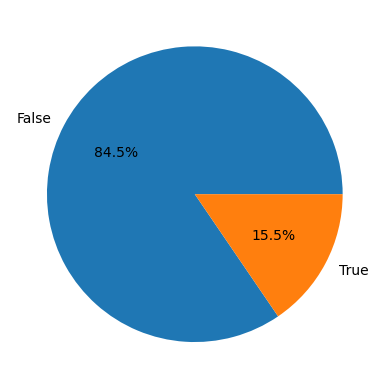

In [47]:
plt.pie(revenue_class_count , labels = ["False","True"], autopct = "%1.1f%%")
plt.show()

In [48]:
shop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

<Axes: >

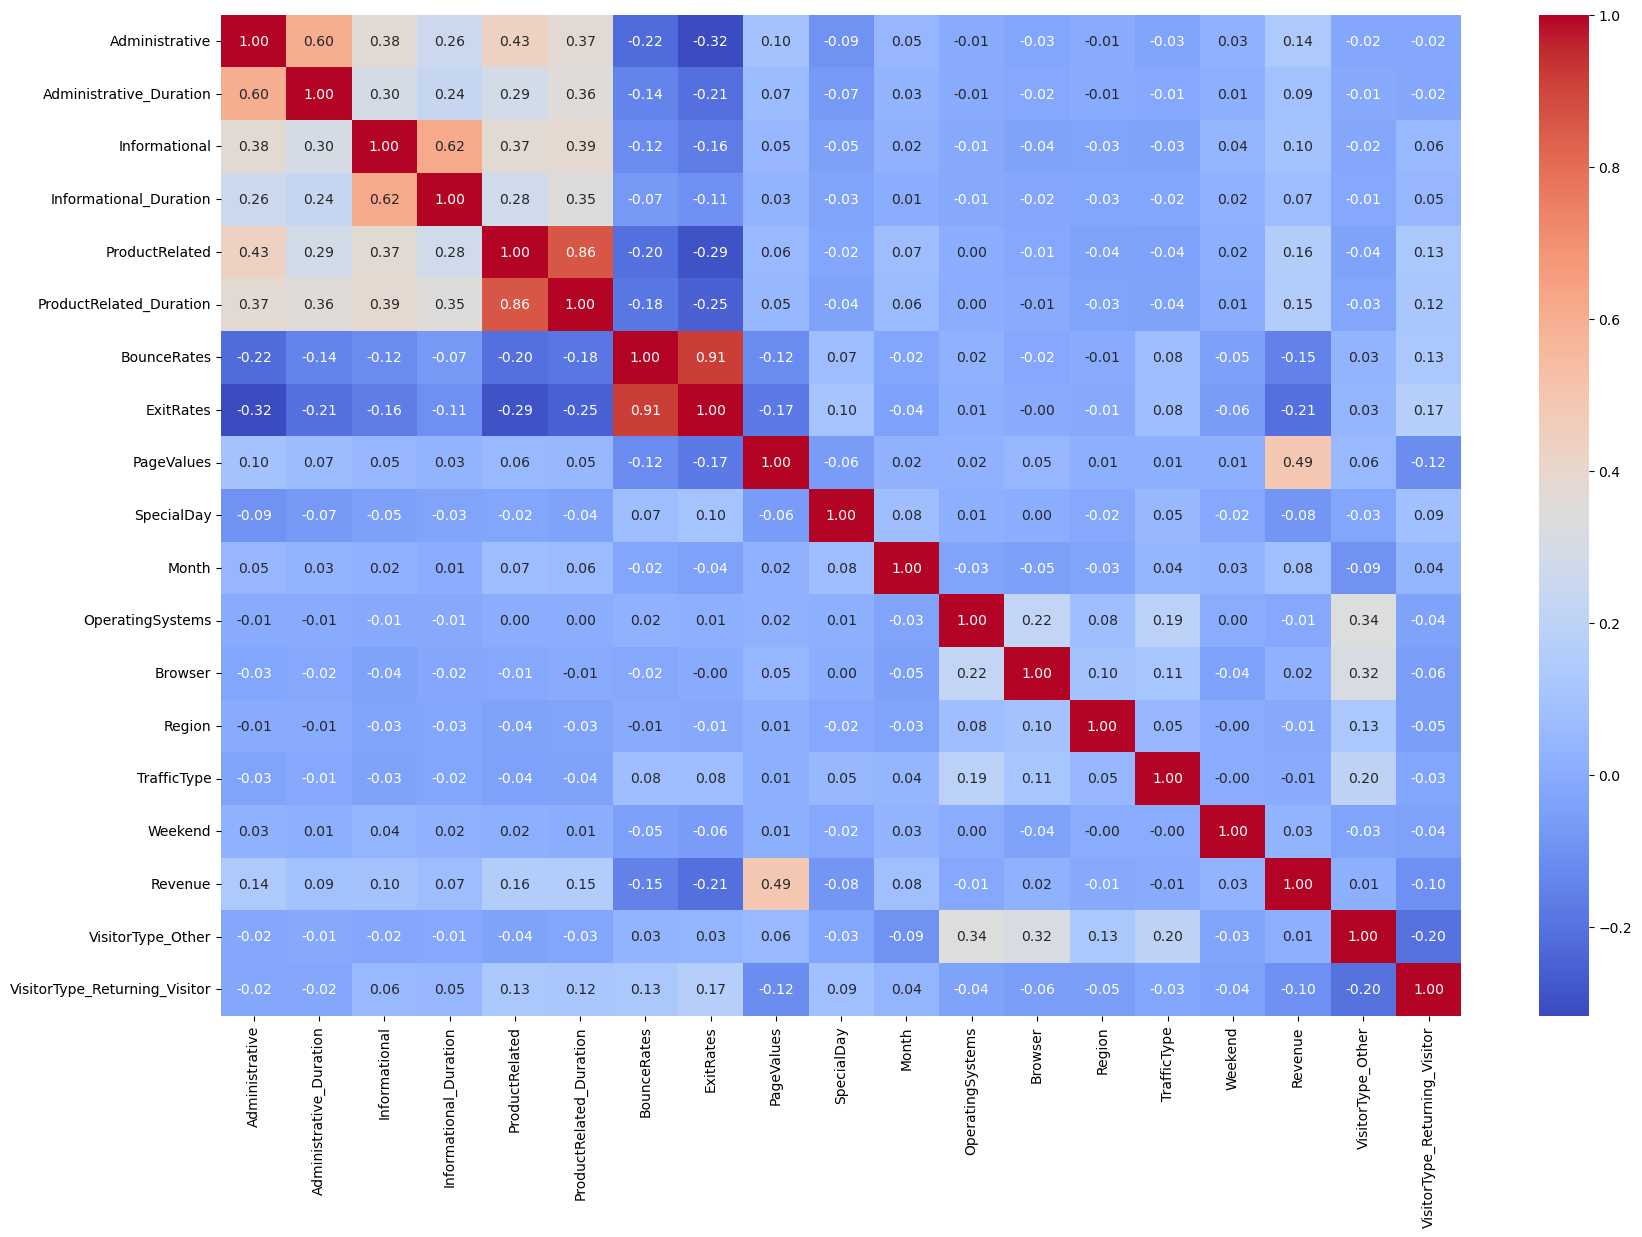

In [65]:
numerical_columns = shop_data.select_dtypes("number")
corr_matrix = numerical_columns.corr()
plt.figure(figsize=(20,13))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [61]:
shop_data["Revenue"].nunique()
shop_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,Returning_Visitor,1,0


In [63]:
# Encoding 

# Categorical Encoding
shop_data["Weekend"] = shop_data["Weekend"].astype(int)
shop_data["Revenue"] = shop_data["Revenue"].astype(int)

# Label Encoding
le = LabelEncoder()
shop_data["Month"] = le.fit_transform(shop_data["Month"])


# One Hot Encoding
ohe = OneHotEncoder(drop = "first",sparse_output = False,dtype = int)
encoded = ohe.fit_transform(shop_data[["VisitorType"]])


encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["VisitorType"]),
    index=shop_data.index
)
shop_data = pd.concat(
    [shop_data.drop("VisitorType", axis=1), encoded_df],
    axis=1
)

In [70]:
X = shop_data.drop(columns= ["Revenue"])
y = shop_data["Revenue"]

In [71]:
X_train , X_test , y_train , y_test = train_test_split(
    X, y , test_size = 0.2 , random_state = 42 
)

In [77]:
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [78]:
y_pred = dt_classifier.predict(X_test)
print(f"f1 score : {f1_score(y_test,y_pred)}")

f1 score : 0.5789473684210527


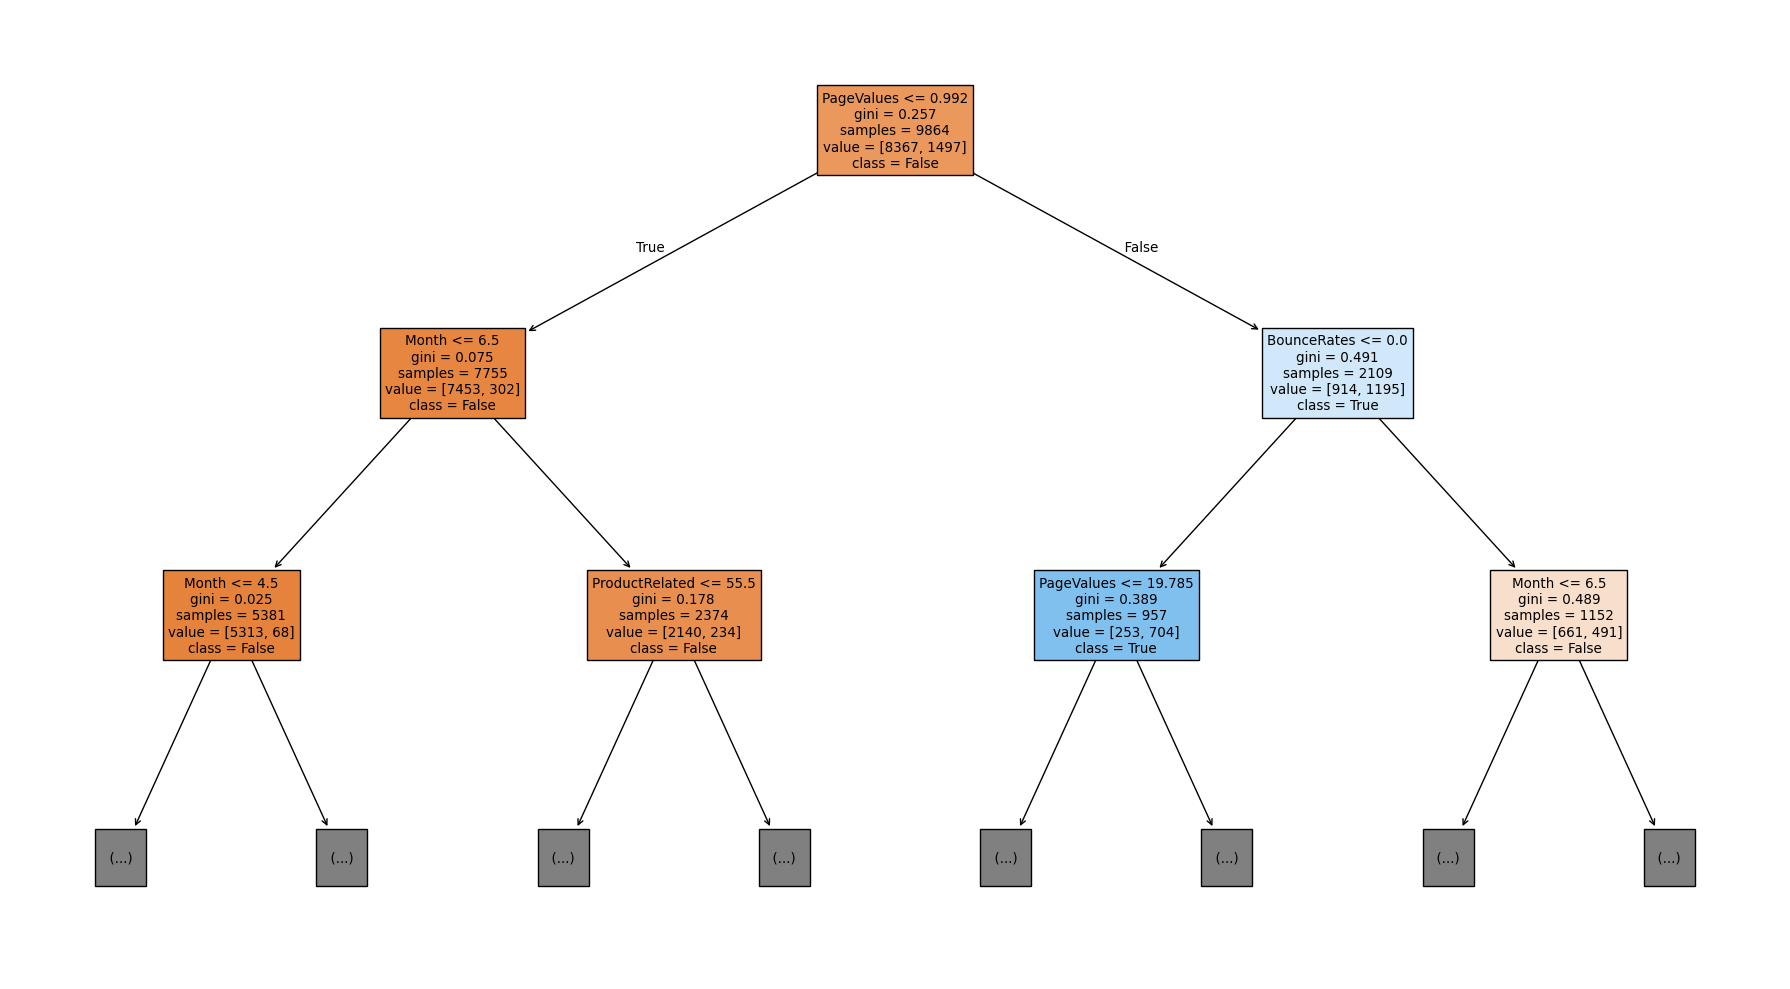

In [81]:
plt.figure(figsize = (18,10))
plot_tree(
    dt_classifier,
    feature_names = X.columns,
    class_names = ["False","True"],
    filled = True, 
    max_depth = 2 
)
plt.tight_layout()
plt.show()

In [85]:
# Pre Pruning 
depths = [2,3,4,5,6,7,8,9]
samples = [3,4,5,10,15,20,25,30,35,40]

for sample in samples:
    dt_classifier = DecisionTreeClassifier(max_depth = 3,min_samples_split=sample)
    dt_classifier.fit(X_train,y_train)
    y_pred = dt_classifier.predict(X_test)
    print(f"for sample : {sample} f1 score : {f1_score(y_test,y_pred)}")

for sample : 3 f1 score : 0.6436781609195402
for sample : 4 f1 score : 0.6436781609195402
for sample : 5 f1 score : 0.6436781609195402
for sample : 10 f1 score : 0.6436781609195402
for sample : 15 f1 score : 0.6436781609195402
for sample : 20 f1 score : 0.6436781609195402
for sample : 25 f1 score : 0.6436781609195402
for sample : 30 f1 score : 0.6436781609195402
for sample : 35 f1 score : 0.6436781609195402
for sample : 40 f1 score : 0.6436781609195402


In [88]:
# Post pruning 
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

In [92]:
# Train model for each aplha and find the best apha value 

best_alpha = 0 
best_accuracy = 0 


for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    accuracy = model.score(X_test,y_test)
    if best_accuracy < accuracy:
        best_accuracy = accuracy
        best_alpha = alpha

f1 score : 0.6407766990291263


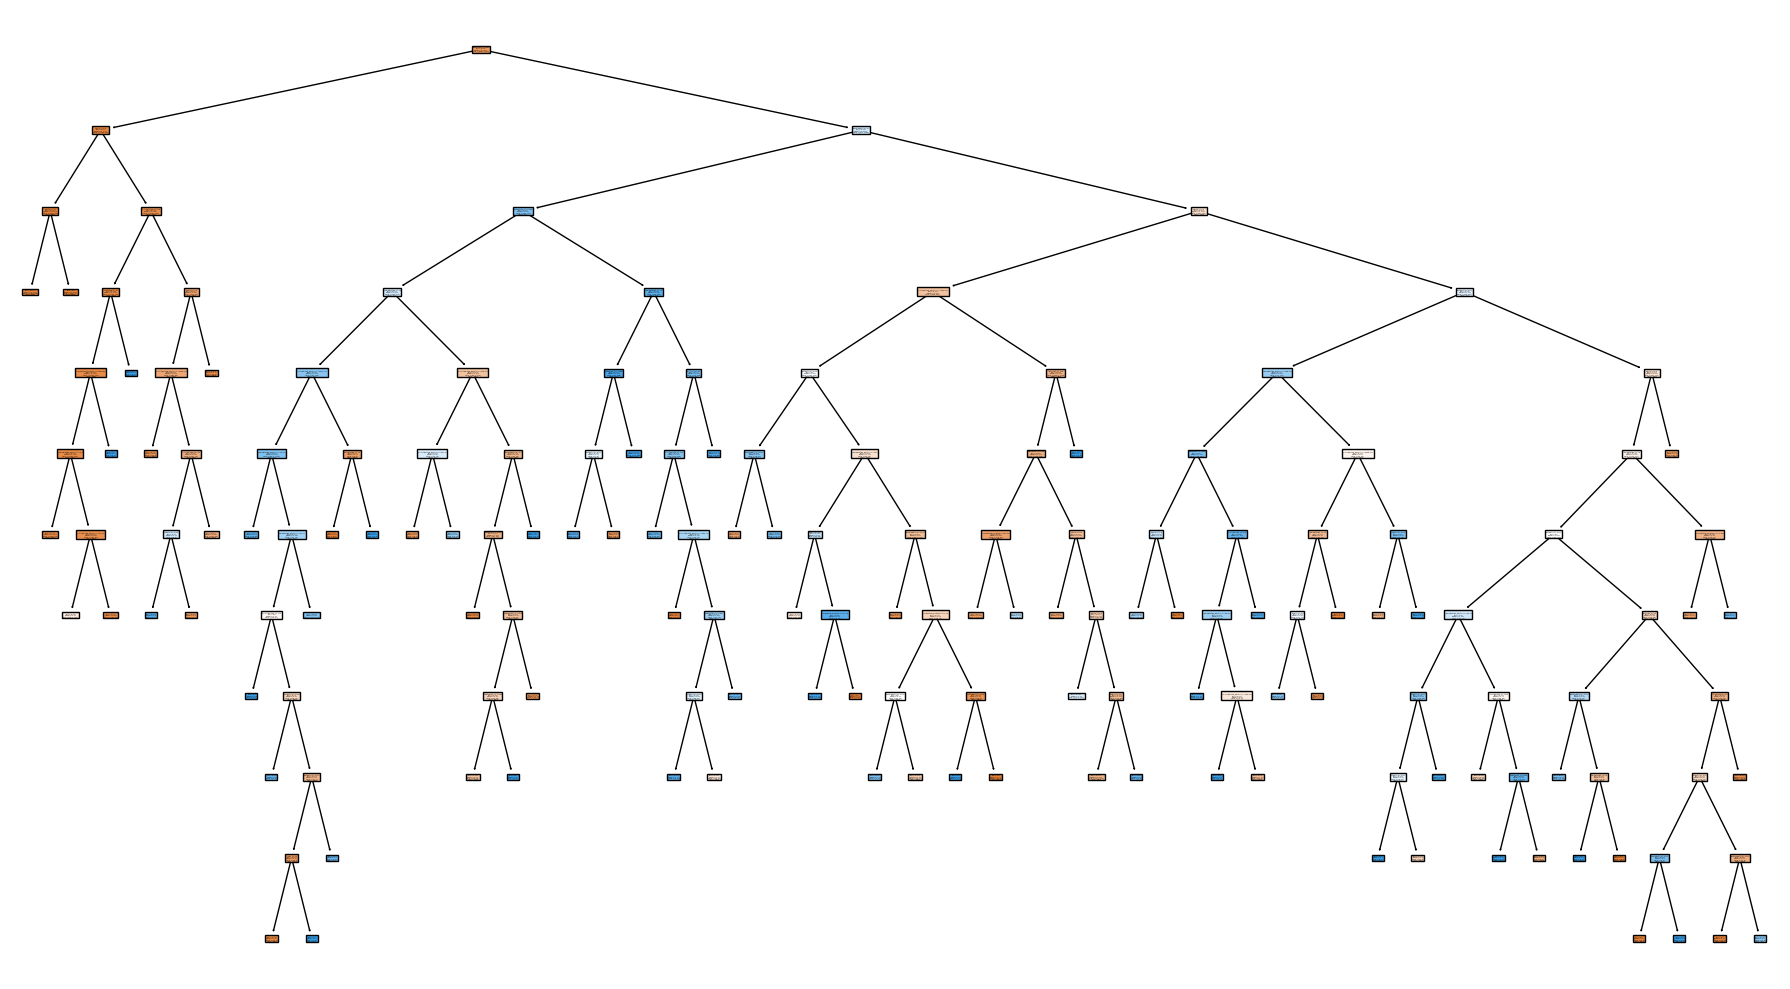

In [97]:
# best model 
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
accuracy = best_model.score(X_test,y_test)
print(f"f1 score : {f1_score(y_test,y_pred)}")

plt.figure(figsize = (18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["False","True"],
    filled = True
)
plt.tight_layout()
plt.show()

In [95]:
print(best_accuracy)
print(best_alpha)

0.8969991889699919
0.00029830103832064175
